In [3]:
import pandas as pd

In [5]:
df = pd.read_csv(r"GroceryStoreDataSet.csv",header=None,names=["products"])
df

,products
0,"MILK,BREAD,BISCUIT"
1,"BREAD,MILK,BISCUIT,CORNFLAKES"
2,"BREAD,TEA,BOURNVITA"
3,"JAM,MAGGI,BREAD,MILK"
4,"MAGGI,TEA,BISCUIT"
5,"BREAD,TEA,BOURNVITA"
6,"MAGGI,TEA,CORNFLAKES"
7,"MAGGI,BREAD,TEA,BISCUIT"
8,"JAM,MAGGI,BREAD,TEA"
9,"BREAD,MILK"


In [6]:
df.shape

(20, 1)

In [10]:
df.values

array([['MILK,BREAD,BISCUIT'],
       ['BREAD,MILK,BISCUIT,CORNFLAKES'],
       ['BREAD,TEA,BOURNVITA'],
       ['JAM,MAGGI,BREAD,MILK'],
       ['MAGGI,TEA,BISCUIT'],
       ['BREAD,TEA,BOURNVITA'],
       ['MAGGI,TEA,CORNFLAKES'],
       ['MAGGI,BREAD,TEA,BISCUIT'],
       ['JAM,MAGGI,BREAD,TEA'],
       ['BREAD,MILK'],
       ['COFFEE,COKE,BISCUIT,CORNFLAKES'],
       ['COFFEE,COKE,BISCUIT,CORNFLAKES'],
       ['COFFEE,SUGER,BOURNVITA'],
       ['BREAD,COFFEE,COKE'],
       ['BREAD,SUGER,BISCUIT'],
       ['COFFEE,SUGER,CORNFLAKES'],
       ['BREAD,SUGER,BOURNVITA'],
       ['BREAD,COFFEE,SUGER'],
       ['BREAD,COFFEE,SUGER'],
       ['TEA,MILK,COFFEE,CORNFLAKES']], dtype=object)

In [12]:
data = list(df["products"].apply(lambda x:x.split(',')))
data 

[['MILK', 'BREAD', 'BISCUIT'],
 ['BREAD', 'MILK', 'BISCUIT', 'CORNFLAKES'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['JAM', 'MAGGI', 'BREAD', 'MILK'],
 ['MAGGI', 'TEA', 'BISCUIT'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['MAGGI', 'TEA', 'CORNFLAKES'],
 ['MAGGI', 'BREAD', 'TEA', 'BISCUIT'],
 ['JAM', 'MAGGI', 'BREAD', 'TEA'],
 ['BREAD', 'MILK'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'COKE'],
 ['BREAD', 'SUGER', 'BISCUIT'],
 ['COFFEE', 'SUGER', 'CORNFLAKES'],
 ['BREAD', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['TEA', 'MILK', 'COFFEE', 'CORNFLAKES']]

In [ ]:
!pip install mlxtend

In [ ]:
pip install numpy==1.14.5

In [ ]:
pip install numpy --upgrade

In [16]:
import numpy as np
np.__version__

'2.1.3'

In [13]:
data

[['MILK', 'BREAD', 'BISCUIT'],
 ['BREAD', 'MILK', 'BISCUIT', 'CORNFLAKES'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['JAM', 'MAGGI', 'BREAD', 'MILK'],
 ['MAGGI', 'TEA', 'BISCUIT'],
 ['BREAD', 'TEA', 'BOURNVITA'],
 ['MAGGI', 'TEA', 'CORNFLAKES'],
 ['MAGGI', 'BREAD', 'TEA', 'BISCUIT'],
 ['JAM', 'MAGGI', 'BREAD', 'TEA'],
 ['BREAD', 'MILK'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'COKE', 'BISCUIT', 'CORNFLAKES'],
 ['COFFEE', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'COKE'],
 ['BREAD', 'SUGER', 'BISCUIT'],
 ['COFFEE', 'SUGER', 'CORNFLAKES'],
 ['BREAD', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['BREAD', 'COFFEE', 'SUGER'],
 ['TEA', 'MILK', 'COFFEE', 'CORNFLAKES']]

In [14]:
from mlxtend.preprocessing import TransactionEncoder

In [15]:
te = TransactionEncoder()
te_data = te.fit(data).transform(data)
df = pd.DataFrame(te_data,columns=te.columns_)
df

,BISCUIT,BOURNVITA,BREAD,COFFEE,COKE,CORNFLAKES,JAM,MAGGI,MILK,SUGER,TEA
0,True,False,True,False,False,False,False,False,True,False,False
1,True,False,True,False,False,True,False,False,True,False,False
2,False,True,True,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,True,True,True,False,False
4,True,False,False,False,False,False,False,True,False,False,True
5,False,True,True,False,False,False,False,False,False,False,True
6,False,False,False,False,False,True,False,True,False,False,True
7,True,False,True,False,False,False,False,True,False,False,True
8,False,False,True,False,False,False,True,True,False,False,True
9,False,False,True,False,False,False,False,False,True,False,False


In [29]:
df.sum().to_frame("Frequency").sort_values("Frequency",ascending=False)

,Frequency
BREAD,13
COFFEE,8
BISCUIT,7
TEA,7
SUGER,6
CORNFLAKES,6
MILK,5
MAGGI,5
BOURNVITA,4
COKE,3


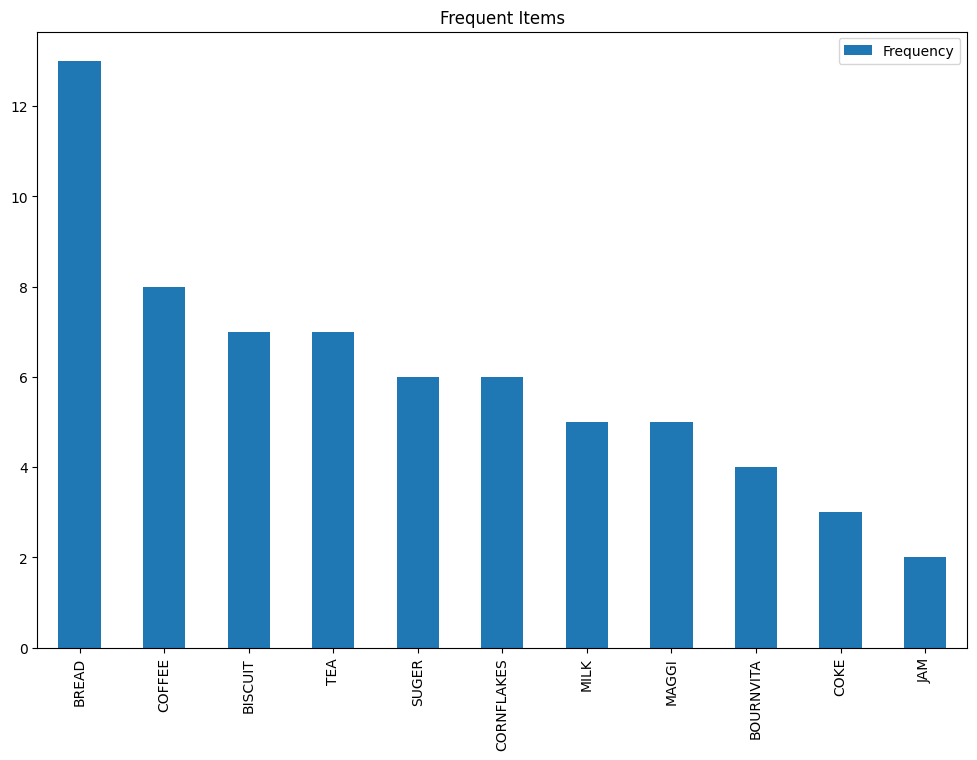

In [30]:
import matplotlib.pyplot as plt 

df.sum().to_frame('Frequency').sort_values('Frequency',ascending=False).plot(kind='bar',
                                                                                  figsize=(12,8),
                                                                                  title="Frequent Items")
plt.show()

In [32]:
df.shape[0]

20

In [33]:
# Product Frequency / Total Sales
first = pd.DataFrame(df.sum() / df.shape[0],columns = ["Support"]).sort_values("Support", ascending = False)
first

,Support
BREAD,0.65
COFFEE,0.40
BISCUIT,0.35
TEA,0.35
SUGER,0.30
CORNFLAKES,0.30
MILK,0.25
MAGGI,0.25
BOURNVITA,0.20
COKE,0.15


In [36]:
# Elimination by Support Value
first[first.Support < 0.20]

,Support
COKE,0.15
JAM,0.10


In [37]:
import itertools

In [40]:
second = list(itertools.combinations(first.index, 4))
second = [list(i) for i in second]
# Sample of combinations
second

[['BREAD', 'COFFEE', 'BISCUIT', 'TEA'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'SUGER'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'CORNFLAKES'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'MILK'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'MAGGI'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'COKE'],
 ['BREAD', 'COFFEE', 'BISCUIT', 'JAM'],
 ['BREAD', 'COFFEE', 'TEA', 'SUGER'],
 ['BREAD', 'COFFEE', 'TEA', 'CORNFLAKES'],
 ['BREAD', 'COFFEE', 'TEA', 'MILK'],
 ['BREAD', 'COFFEE', 'TEA', 'MAGGI'],
 ['BREAD', 'COFFEE', 'TEA', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'TEA', 'COKE'],
 ['BREAD', 'COFFEE', 'TEA', 'JAM'],
 ['BREAD', 'COFFEE', 'SUGER', 'CORNFLAKES'],
 ['BREAD', 'COFFEE', 'SUGER', 'MILK'],
 ['BREAD', 'COFFEE', 'SUGER', 'MAGGI'],
 ['BREAD', 'COFFEE', 'SUGER', 'BOURNVITA'],
 ['BREAD', 'COFFEE', 'SUGER', 'COKE'],
 ['BREAD', 'COFFEE', 'SUGER', 'JAM'],
 ['BREAD', 'COFFEE', 'CORNFLAKES', 'MILK'],
 ['BREAD', 'COFFEE', 'CORNFLAKES', 'MAGGI'],
 ['BREAD', 'COFFEE', 'CORNFLAKES', 'BOURNVITA'],
 ['BREA

In [41]:
from mlxtend.frequent_patterns import apriori

In [54]:
df1 = apriori(df,min_support=0.001,use_colnames=True)
df1

,support,itemsets
0,0.35,frozenset({BISCUIT})
1,0.20,frozenset({BOURNVITA})
2,0.65,frozenset({BREAD})
3,0.40,frozenset({COFFEE})
4,0.15,frozenset({COKE})
...,...,...
78,0.05,"frozenset({TEA, MAGGI, BISCUIT, BREAD})"
79,0.10,"frozenset({COKE, CORNFLAKES, BISCUIT, COFFEE})"
80,0.05,"frozenset({MAGGI, JAM, MILK, BREAD})"
81,0.05,"frozenset({TEA, MAGGI, JAM, BREAD})"


In [55]:
df1.head(20).sort_values(by="support",ascending=False)

,support,itemsets
2,0.65,frozenset({BREAD})
3,0.40,frozenset({COFFEE})
0,0.35,frozenset({BISCUIT})
10,0.35,frozenset({TEA})
9,0.30,frozenset({SUGER})
5,0.30,frozenset({CORNFLAKES})
8,0.25,frozenset({MILK})
7,0.25,frozenset({MAGGI})
1,0.20,frozenset({BOURNVITA})
11,0.20,"frozenset({BISCUIT, BREAD})"


In [56]:
df1['length'] = df1['itemsets'].apply(lambda x:len(x))
df1

,support,itemsets,length
0,0.35,frozenset({BISCUIT}),1
1,0.20,frozenset({BOURNVITA}),1
2,0.65,frozenset({BREAD}),1
3,0.40,frozenset({COFFEE}),1
4,0.15,frozenset({COKE}),1
...,...,...,...
78,0.05,"frozenset({TEA, MAGGI, BISCUIT, BREAD})",4
79,0.10,"frozenset({COKE, CORNFLAKES, BISCUIT, COFFEE})",4
80,0.05,"frozenset({MAGGI, JAM, MILK, BREAD})",4
81,0.05,"frozenset({TEA, MAGGI, JAM, BREAD})",4


In [59]:
df1[(df1['length']==2) & (df1['support']>=0.05)]

,support,itemsets,length
11,0.20,"frozenset({BISCUIT, BREAD})",2
12,0.10,"frozenset({BISCUIT, COFFEE})",2
13,0.10,"frozenset({COKE, BISCUIT})",2
14,0.15,"frozenset({CORNFLAKES, BISCUIT})",2
15,0.10,"frozenset({MAGGI, BISCUIT})",2
16,0.10,"frozenset({BISCUIT, MILK})",2
17,0.05,"frozenset({SUGER, BISCUIT})",2
18,0.10,"frozenset({TEA, BISCUIT})",2
19,0.15,"frozenset({BOURNVITA, BREAD})",2
20,0.05,"frozenset({BOURNVITA, COFFEE})",2


In [60]:
from mlxtend.frequent_patterns import association_rules

In [61]:
# Association Rules & Info
df_ar = association_rules(df1, metric = "confidence", min_threshold = 0.2)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({BISCUIT}),frozenset({BREAD}),0.35,0.65,0.20,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.250000,-0.224490,0.439560
1,frozenset({BREAD}),frozenset({BISCUIT}),0.65,0.35,0.20,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.250000,-0.065089,0.439560
2,frozenset({BISCUIT}),frozenset({COFFEE}),0.35,0.40,0.10,0.285714,0.714286,1.0,-0.0400,0.840000,-0.380952,0.153846,-0.190476,0.267857
3,frozenset({COFFEE}),frozenset({BISCUIT}),0.40,0.35,0.10,0.250000,0.714286,1.0,-0.0400,0.866667,-0.400000,0.153846,-0.153846,0.267857
4,frozenset({COKE}),frozenset({BISCUIT}),0.15,0.35,0.10,0.666667,1.904762,1.0,0.0475,1.950000,0.558824,0.250000,0.487179,0.476190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,"frozenset({TEA, MILK})","frozenset({CORNFLAKES, COFFEE})",0.05,0.20,0.05,1.000000,5.000000,1.0,0.0400,inf,0.842105,0.250000,1.000000,0.625000
260,"frozenset({CORNFLAKES, COFFEE})","frozenset({TEA, MILK})",0.20,0.05,0.05,0.250000,5.000000,1.0,0.0400,1.266667,1.000000,0.250000,0.210526,0.625000
261,"frozenset({CORNFLAKES, MILK})","frozenset({TEA, COFFEE})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
262,"frozenset({COFFEE, MILK})","frozenset({TEA, CORNFLAKES})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000


* Antecedent support variable tells us probability of antecedent products alone
* Consequents support variable tells us probability of consequents products alone
* The support value is the value of the two products (Antecedents and Consequents)
* Confidence is an indication of how often the rule has been found to be true.
* The ratio of the observed support to that expected if X and Y were independent.

**Lift indicates:**

1. Whether if two type of products can be sold together - lift value higher than 1
2. Whether 1 product be substitute of other - lift value lower than 1
3. Whether if there is no relation between the type or products - lift value equals to 1

In [71]:
df_ar[(df_ar.support >0.15) & (df_ar.confidence > 0.70) & (df_ar.lift > 1.0)].sort_values("confidence", ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
27,frozenset({MILK}),frozenset({BREAD}),0.25,0.65,0.2,0.8,1.230769,1.0,0.0375,1.75,0.25,0.285714,0.428571,0.553846
55,frozenset({MAGGI}),frozenset({TEA}),0.25,0.35,0.2,0.8,2.285714,1.0,0.1125,3.25,0.75,0.500000,0.692308,0.685714


**For MILK-BREAD pair:** antecedent support=0.25: Milk is observed in 25% of all the purchases. consequent support=0.65: Bread is observed 65% of all the purchases. support=0.20 : Milk and Bread are observed together in 20% of all purchases. confidence=0.8: If Milk is bought, Bread is 80% likely to be bought as well. Lift=1.23: That means Milk and Bread affects each other's sales positively. Sales of Bread increase by 1.23 times in transactions which contains Milk or visa versa.

**For MAGGI-TEA pair:** antecedent support=0.25: Maggi is observed in 25% of all the purchases. consequent support=0.35: Tea is observed 35% of all the purchases. support=0.20 : Maggi and Tea are observed together in 20% of all purchases. confidence=0.8: If Maggi is bought, Tea is 80% likely to be bought as well. Lift=2.286: That means Maggi and Tea affects each other's sales positively. Sales of Maggi increase by 2.286 times in transactions which contains Tea or visa versa.

In [72]:
df_lift = association_rules(df1, metric = 'lift', min_threshold = 5) 
# displaying results with lift >= 1
df_lift.sort_values(by = 'lift', ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,"frozenset({MAGGI, MILK})",frozenset({JAM}),0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000
5,frozenset({JAM}),"frozenset({MAGGI, MILK})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
12,"frozenset({BISCUIT, COFFEE})","frozenset({COKE, CORNFLAKES})",0.10,0.10,0.10,1.000000,10.000000,1.0,0.0900,inf,1.000000,1.000000,1.000000,1.000000
9,"frozenset({COKE, CORNFLAKES})","frozenset({BISCUIT, COFFEE})",0.10,0.10,0.10,1.000000,10.000000,1.0,0.0900,inf,1.000000,1.000000,1.000000,1.000000
7,"frozenset({BISCUIT, MILK})","frozenset({CORNFLAKES, BREAD})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
6,"frozenset({CORNFLAKES, BREAD})","frozenset({BISCUIT, MILK})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000
25,"frozenset({TEA, COFFEE})","frozenset({CORNFLAKES, MILK})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000
24,"frozenset({TEA, CORNFLAKES})","frozenset({COFFEE, MILK})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
28,"frozenset({CORNFLAKES, MILK})","frozenset({TEA, COFFEE})",0.10,0.05,0.05,0.500000,10.000000,1.0,0.0450,1.900000,1.000000,0.500000,0.473684,0.750000
29,"frozenset({COFFEE, MILK})","frozenset({TEA, CORNFLAKES})",0.05,0.10,0.05,1.000000,10.000000,1.0,0.0450,inf,0.947368,0.500000,1.000000,0.750000


In [ ]:
df_lift = association_rules(df1, metric = 'lift', min_threshold = 0) # displaying results with lift >= 0
df_lift[df_lift['lift'] == 1]